In [1]:
# ==============================================================================
# الخلية 1: استخراج الميزات (نفس المنهجية — محققة خالية من Leakage)
# ==============================================================================
# ✅ جميع دوال المعالجة تعمل per-frame بشكل مستقل — لا leakage
# ✅ StandardScaler داخل LOSO loop — لا leakage
# ⚠ تحقق مضاف: التأكد من أن subject_id يمثل شخصاً حقيقياً واحداً

import os
import glob
import re
import time
import warnings
import numpy as np
import pandas as pd
from scipy.linalg import sqrtm, inv
from scipy.interpolate import griddata
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ── إعدادات الحساس والقناع الدائري ──────────────────────────────
ROWS, COLS             = 34, 16
CENTER_ROW, CENTER_COL = 16.5, 7.5
RADIUS                 = 6.0
EPS                    = 1e-10

_ri, _ci = np.indices((ROWS, COLS))
MASK_2D  = np.sqrt((_ri - CENTER_ROW)**2 + (_ci - CENTER_COL)**2) <= RADIUS
N_ACTIVE_PIXELS = int(MASK_2D.sum())

# ── دالة قراءة اسم الملف ─────────────────────────────────────────
_COND_PATTERN = re.compile(r'[-_]?[FMfm][-_]?([LN])\d*$|[-_]([LN])\d*$')

def parse_condition(filepath):
    name  = os.path.basename(filepath).upper().replace('.CSV', '')
    match = _COND_PATTERN.search(name)
    if not match:
        return None
    letter = match.group(1) or match.group(2)
    return 'Normal' if letter == 'N' else 'Low Iron'

# ── دوال المعالجة — كلها per-frame (لا leakage) ──────────────────
def apply_energy_normalization(frame_2d):
    e = np.clip(frame_2d, 0, None)
    s = np.sum(e)
    return e / s if s > 0 else e

def apply_whitening_transform(energy_map):
    rows, cols   = energy_map.shape
    y, x         = np.indices((rows, cols))
    coords       = np.stack([x.ravel(), y.ravel()], axis=0).astype(float)
    weights      = energy_map.ravel()
    total_weight = np.sum(weights)
    
    if total_weight <= 0:
        return energy_map
        
    mean_pos = np.sum(coords * weights, axis=1, keepdims=True) / total_weight
    centered = coords - mean_pos
    cov      = (centered * weights) @ centered.T / total_weight
    cov      = (cov + cov.T) / 2
    
    try:
        W      = inv(sqrtm(cov + np.eye(2) * 1e-6))
        wc     = W @ centered
        wx, wy = wc[0], wc[1]
        
        def rescale(arr, lo, hi):
            a, b = arr.min(), arr.max()
            if a == b:
                return np.full_like(arr, (lo + hi) / 2)
            return (arr - a) / (b - a) * (hi - lo) + lo
            
        wx_s   = rescale(wx, 0, cols - 1)
        wy_s   = rescale(wy, 0, rows - 1)
        gy, gx = np.mgrid[0:rows, 0:cols]
        w_map  = griddata(
            np.stack([wx_s, wy_s], axis=1),
            weights, (gx, gy),
            method='linear', fill_value=0.0
        )
        return np.clip(w_map, 0, None)
    except Exception:
        return energy_map

def apply_zscore_normalization(energy_map):
    mean_v = np.mean(energy_map)
    std_v  = np.std(energy_map)
    z      = (energy_map - mean_v) / (std_v if std_v > 0 else 1)
    z      = z - np.min(z)
    s      = np.sum(z)
    return z / s if s > 0 else z

# ── دالة معالجة ملف واحد ─────────────────────────────────────────
def process_single_file(file):
    condition = parse_condition(file)
    if condition is None:
        return []
        
    match      = re.search(r'(?:R\d+[-_])([A-Z]+)', os.path.basename(file).upper().replace('.CSV',''))
    subject_id = match.group(1) if match else os.path.basename(file)
    dataset = []
    
    try:
        df = pd.read_csv(file, on_bad_lines='skip')
        for idx in range(len(df)):
            delta_str = (str(df['delta_values'].iloc[idx])
                         .replace('OK 34 16', '').replace('\n', ''))
            try:
                delta_raw = np.array([float(x.strip()) for x in delta_str.split(',') if x.strip()])
            except Exception:
                continue
                
            if len(delta_raw) != 544:
                continue
                
            raw_2d           = delta_raw.reshape(ROWS, COLS).copy()
            raw_2d[~MASK_2D] = 0
            
            final_map = apply_zscore_normalization(
                apply_whitening_transform(
                    apply_energy_normalization(raw_2d)
                )
            )
            
            flat   = final_map.flatten()
            active = flat[flat > 0]
            n_px   = len(active)
            
            if n_px < 5:
                continue
                
            y_coords, x_coords = np.where(final_map > 0)
            distances = np.sqrt((y_coords - CENTER_ROW)**2 + (x_coords - CENTER_COL)**2)
            weights = final_map[y_coords, x_coords]
            
            active_area      = float(n_px)
            core_mask        = distances <= (RADIUS / 3)
            mid_mask         = (distances > (RADIUS / 3)) & (distances <= (2 * RADIUS / 3))
            
            core_energy      = np.sum(weights[core_mask])
            mid_energy       = np.sum(weights[mid_mask])
            core_mid_ratio   = core_energy / (mid_energy + EPS)
            
            mean_dist        = np.sum(weights * distances) / (np.sum(weights) + EPS)
            radial_curvature = np.sum(weights * ((distances - mean_dist)**2)) / (np.sum(weights) + EPS)
            
            dataset.append({
                'subject_id':       subject_id,
                'Condition':        condition,
                'active_area':      active_area,
                'radial_curvature': radial_curvature,
                'core_mid_ratio':   core_mid_ratio
            })
    except Exception:
        pass
        
    return dataset

# ── التشغيل المتوازي ──────────────────────────────────────────────
folder_path = r"C:\Users\Abrar Matar\OneDrive\سطح المكتب\المواد\مشروع تخرج\data\final"
csv_files   = glob.glob(os.path.join(folder_path, "*.csv"))

print(f"🚀 بدء معالجة {len(csv_files)} ملف...")
start_time = time.time()

results = Parallel(n_jobs=-1, backend='loky')(
    delayed(process_single_file)(f) for f in tqdm(csv_files, desc="Processing")
)

final_df = pd.DataFrame([item for sublist in results for item in sublist])

print(f"✅ اكتمل في {(time.time()-start_time)/60:.2f} دقيقة")
print(f"📊 {len(final_df):,} إطار | {final_df['subject_id'].nunique()} مشارك")
print(final_df['Condition'].value_counts().to_string())

# ── تحقق سلامة: هل كل subject_id له تصنيف واحد فقط؟ ──────────────
subject_cond = final_df.groupby('subject_id')['Condition'].nunique()
mixed = subject_cond[subject_cond > 1]

if len(mixed) > 0:
    print(f"\n⚠️ تحذير: {len(mixed)} مشارك لديه أكثر من تصنيف — يرجى مراجعة الـ subject_id:")
    print(mixed.to_string())
else:
    print("\n✅ سلامة الـ Groups: كل مشارك له تصنيف واحد فقط — LOSO آمن")

🚀 بدء معالجة 71 ملف...


Processing:   0%|          | 0/71 [00:00<?, ?it/s]

✅ اكتمل في 0.57 دقيقة
📊 18,978 إطار | 18 مشارك
Condition
Low Iron    10220
Normal       8758

✅ سلامة الـ Groups: كل مشارك له تصنيف واحد فقط — LOSO آمن


🧠 Logistic Regression — LOSO + Soft Voting + Bootstrap CI + Feature Importance
   إطارات: 18,978 | مشاركون: 18 | ميزات: 2
   C candidates: [0.0001, 0.001, 0.01, 0.1, 1.0]

📊 Frame-Level:
   Accuracy : 62.4%
   Recall   : 60.0%
   F1-Score : 63.2%

🗳️  Subject-Level (Soft Voting):
   Accuracy : 83.3%
   Recall   : 70.0%
   F1-Score : 82.4%
   ROC-AUC  : 81.2%

📐 Bootstrap 95% CI — Subject Accuracy: [66.7% , 100.0%]
   (يعني: الدقة الحقيقية على الأرجح بين 66.7% و 100.0%)

🔧 توزيع أفضل C عبر الـ folds: {0.0001: 12, 1.0: 2, 0.001: 3, 0.1: 1}

⚖️ تحليل أوزان الميزات (Coefficients Analysis):
🔹 active_area        :  0.3785 (± 0.2527) ⬅️ يزيد من احتمالية (Low Iron) 🔴
🔹 core_mid_ratio     : -0.1571 (± 0.0919) ⬅️ يزيد من احتمالية (Normal) 🟢
----------------------------------------------------------------------
💡 كيف تقرأ هذه الأرقام؟
- الرقم الأكبر كقيمة مطلقة (بغض النظر عن الإشارة) هو الميزة الأهم في اتخاذ القرار.
- بما أن الفئة (1) هي Low Iron، فإن الوزن الموجب يعني أن زيادة قيمة الميزة تدفع ل

,المشارك,الحالة الحقيقية,Soft Score,أصوات Low Iron,أصوات Normal,التشخيص,أفضل C,النتيجة
0,ALSHAYMAA,Normal,0.46,173/1093,920/1093,Normal,0.0001,✅
1,AMAL,Low Iron,0.50,435/826,391/826,Low Iron,0.0001,✅
2,ASAL,Normal,0.48,378/1077,699/1077,Normal,0.0001,✅
3,BUSHRA,Normal,0.49,578/1096,518/1096,Normal,1.0000,✅
4,FANAR,Normal,0.48,385/1102,717/1102,Normal,0.0001,✅
5,HAMMED,Normal,0.48,556/1094,538/1094,Normal,0.0010,✅
6,KHALAF,Normal,0.45,379/1099,720/1099,Normal,0.1000,✅
7,LAMYA,Low Iron,0.49,391/1071,680/1071,Normal,0.0001,❌
8,MAHA,Low Iron,0.45,234/1106,872/1106,Normal,0.0001,❌
9,MALAK,Low Iron,0.51,784/1094,310/1094,Low Iron,0.0001,✅


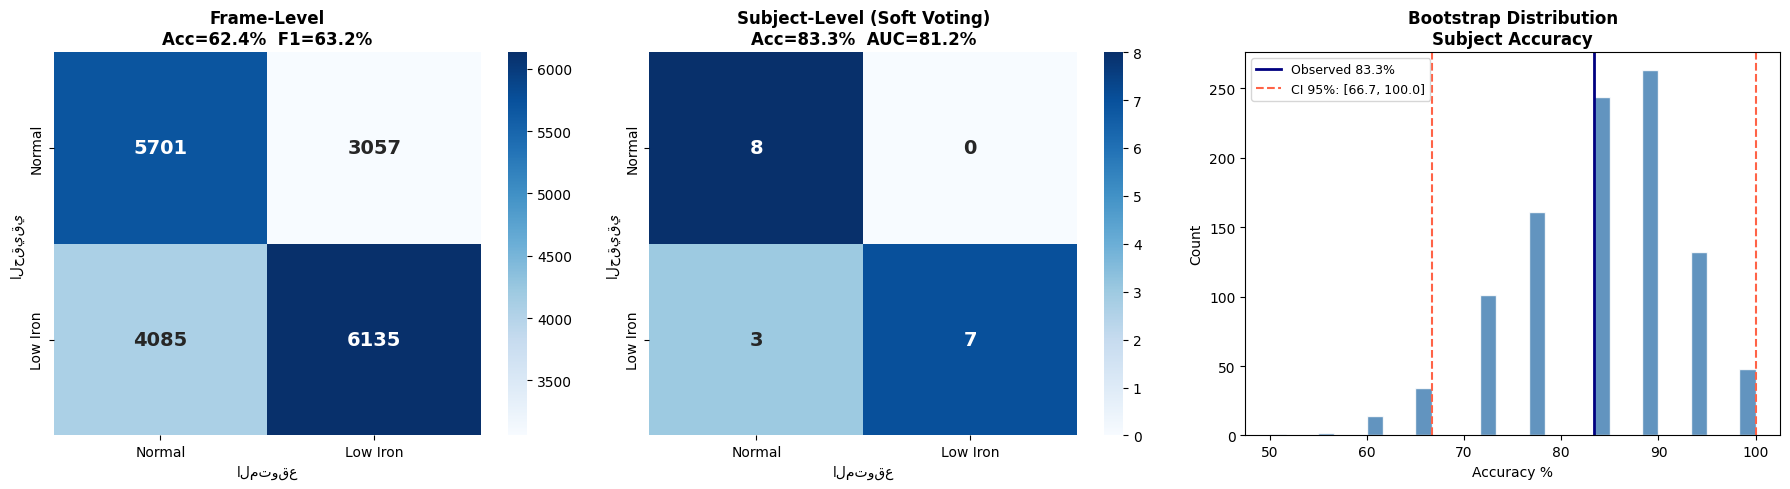


📋 تقرير Subject-Level كامل:
              precision    recall  f1-score   support

      Normal       0.73      1.00      0.84         8
    Low Iron       1.00      0.70      0.82        10

    accuracy                           0.83        18
   macro avg       0.86      0.85      0.83        18
weighted avg       0.88      0.83      0.83        18



In [2]:
# ==============================================================================
# الخلية 2: التدريب — LOSO + Soft Voting + Bootstrap CI + Feature Importance
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_auc_score)

if 'final_df' not in locals() or final_df.empty:
    print("❌ يرجى تشغيل الخلية الأولى أولاً.")
else:
    FEATURES = ['active_area', 'core_mid_ratio']
    C_GRID   = [0.0001, 0.001, 0.01, 0.1, 1.0]
    
    X      = final_df[FEATURES].values
    y      = (final_df['Condition'] == 'Low Iron').astype(int).values
    groups = final_df['subject_id'].values
    logo   = LeaveOneGroupOut()
    
    print("=" * 70)
    print("🧠 Logistic Regression — LOSO + Soft Voting + Bootstrap CI + Feature Importance")
    print(f"   إطارات: {len(X):,} | مشاركون: {len(np.unique(groups))} | ميزات: {len(FEATURES)}")
    print(f"   C candidates: {C_GRID}")
    print("=" * 70)
    
    frame_true, frame_pred, frame_proba = [], [], []
    subject_true, subject_pred, subject_proba = [], [], []
    subject_details = []
    best_C_list = []
    
    # ── [إضافة جديدة] قائمة لتخزين الأوزان في كل لفة ─────────────────
    all_coefficients = []
    
    for train_idx, test_idx in logo.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        g_train         = groups[train_idx]
        
        # ── [تحسين 2] اختيار C داخل LOSO loop بـ GroupKFold ──────
        n_inner = min(3, len(np.unique(g_train)))
        if n_inner >= 2:
            inner_cv = GroupKFold(n_splits=n_inner)
            best_C, best_score = C_GRID[0], -1
            
            for c in C_GRID:
                inner_model = Pipeline([
                    ('scaler', StandardScaler()),
                    ('classifier', LogisticRegression(
                        C=c, solver='liblinear', max_iter=1000,
                        class_weight='balanced', random_state=42))
                ])
                inner_scores = []
                for itr, ite in inner_cv.split(X_train, y_train, g_train):
                    inner_model.fit(X_train[itr], y_train[itr])
                    inner_scores.append(f1_score(y_train[ite], inner_model.predict(X_train[ite]), zero_division=0))
                
                avg = np.mean(inner_scores)
                if avg > best_score:
                    best_score, best_C = avg, c
        else:
            best_C = 0.01
            
        best_C_list.append(best_C)
        
        # ── تدريب النموذج النهائي بأفضل C ────────────────────────
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(
                C=best_C, solver='liblinear', max_iter=1000,
                class_weight='balanced', random_state=42))
        ])
        
        pipeline.fit(X_train, y_train)
        
        # ── [إضافة جديدة] استخراج الأوزان الحالية للميزات ──────────────
        current_weights = pipeline.named_steps['classifier'].coef_[0]
        all_coefficients.append(current_weights)
        
        y_pred_frames  = pipeline.predict(X_test)
        y_proba_frames = pipeline.predict_proba(X_test)[:, 1]
        
        # Frame-level
        frame_true.extend(y_test.tolist())
        frame_pred.extend(y_pred_frames.tolist())
        frame_proba.extend(y_proba_frames.tolist())
        
        # ── [تحسين 1] Soft Voting ──────────────────────────────────
        soft_score    = float(np.mean(y_proba_frames))
        soft_decision = 1 if soft_score >= 0.5 else 0
        true_label    = int(y_test[0])
        subject_name  = groups[test_idx][0]
        
        subject_true.append(true_label)
        subject_pred.append(soft_decision)
        subject_proba.append(soft_score)
        
        vote_counts    = Counter(y_pred_frames)
        total_frames   = len(y_pred_frames)
        low_iron_votes = vote_counts.get(1, 0)
        normal_votes   = vote_counts.get(0, 0)
        
        correct  = "✅" if soft_decision == true_label else "❌"
        true_str = "Low Iron" if true_label == 1 else "Normal"
        pred_str = "Low Iron" if soft_decision == 1 else "Normal"
        
        subject_details.append({
            'المشارك':          subject_name,
            'الحالة الحقيقية':  true_str,
            'Soft Score':       f"{soft_score:.2f}",
            'أصوات Low Iron':   f"{low_iron_votes}/{total_frames}",
            'أصوات Normal':     f"{normal_votes}/{total_frames}",
            'التشخيص':          pred_str,
            'أفضل C':           best_C,
            'النتيجة':          correct,
        })
        
    # ── المقاييس الأساسية ────────────────────────────────────────
    f_acc    = accuracy_score(frame_true, frame_pred) * 100
    f_recall = recall_score(frame_true, frame_pred) * 100
    f_f1     = f1_score(frame_true, frame_pred) * 100
    
    s_acc    = accuracy_score(subject_true, subject_pred) * 100
    s_recall = recall_score(subject_true, subject_pred) * 100
    s_f1     = f1_score(subject_true, subject_pred) * 100
    
    try:
        s_auc = roc_auc_score(subject_true, subject_proba) * 100
    except Exception:
        s_auc = float('nan')
        
    print("\n📊 Frame-Level:")
    print(f"   Accuracy : {f_acc:.1f}%")
    print(f"   Recall   : {f_recall:.1f}%")
    print(f"   F1-Score : {f_f1:.1f}%")
    
    print("\n🗳️  Subject-Level (Soft Voting):")
    print(f"   Accuracy : {s_acc:.1f}%")
    print(f"   Recall   : {s_recall:.1f}%")
    print(f"   F1-Score : {s_f1:.1f}%")
    print(f"   ROC-AUC  : {s_auc:.1f}%")
    
    # ── [تحسين 3] Bootstrap Confidence Interval ──────────────────
    np.random.seed(42)
    N_BOOT       = 1000
    sub_true_arr = np.array(subject_true)
    sub_pred_arr = np.array(subject_pred)
    boot_accs    = []
    
    for _ in range(N_BOOT):
        idx = np.random.choice(len(sub_true_arr), len(sub_true_arr), replace=True)
        boot_accs.append(accuracy_score(sub_true_arr[idx], sub_pred_arr[idx]) * 100)
        
    ci_lo = np.percentile(boot_accs, 2.5)
    ci_hi = np.percentile(boot_accs, 97.5)
    
    print(f"\n📐 Bootstrap 95% CI — Subject Accuracy: [{ci_lo:.1f}% , {ci_hi:.1f}%]")
    print(f"   (يعني: الدقة الحقيقية على الأرجح بين {ci_lo:.1f}% و {ci_hi:.1f}%)")
    
    c_counts = Counter(best_C_list)
    print(f"\n🔧 توزيع أفضل C عبر الـ folds: {dict(c_counts)}")
    
    # ── [تحسين 4] تحليل أوزان النموذج (Feature Importance) ─────────
    print("\n" + "=" * 70)
    print("⚖️ تحليل أوزان الميزات (Coefficients Analysis):")
    print("=" * 70)
    
    weights_df = pd.DataFrame(all_coefficients, columns=FEATURES)
    mean_weights = weights_df.mean()
    std_weights = weights_df.std()
    
    # ترتيب الميزات حسب تأثيرها المطلق (من الأقوى للأضعف)
    sorted_features = mean_weights.abs().sort_values(ascending=False).index
    
    for feature in sorted_features:
        weight = mean_weights[feature]
        std = std_weights[feature]
        
        # تحديد اتجاه التأثير
        impact = "يزيد من احتمالية (Low Iron) 🔴" if weight > 0 else "يزيد من احتمالية (Normal) 🟢"
        
        print(f"🔹 {feature:<18} : {weight:>7.4f} (± {std:.4f}) ⬅️ {impact}")
    
    print("-" * 70)
    print("💡 كيف تقرأ هذه الأرقام؟")
    print("- الرقم الأكبر كقيمة مطلقة (بغض النظر عن الإشارة) هو الميزة الأهم في اتخاذ القرار.")
    print("- بما أن الفئة (1) هي Low Iron، فإن الوزن الموجب يعني أن زيادة قيمة الميزة تدفع للتشخيص بالمرض.")
    print("- الوزن السالب يعني أن زيادة الميزة تدفع للتشخيص بالسليم (Normal).")
    
    print("\n" + "=" * 70)
    print("🔎 تفاصيل كل مشارك:")
    details_df = pd.DataFrame(subject_details)
    display(details_df)
    
    # ── الرسوم البيانية ───────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # [أ] Confusion Matrix — Frame Level
    sns.heatmap(confusion_matrix(frame_true, frame_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Low Iron'],
                yticklabels=['Normal', 'Low Iron'],
                annot_kws={"size": 14, "weight": "bold"}, ax=axes[0])
    axes[0].set_title(f'Frame-Level\nAcc={f_acc:.1f}%  F1={f_f1:.1f}%', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('الحقيقي'); axes[0].set_xlabel('المتوقع')
    
    # [ب] Confusion Matrix — Subject Level (Soft Voting)
    sns.heatmap(confusion_matrix(subject_true, subject_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Low Iron'],
                yticklabels=['Normal', 'Low Iron'],
                annot_kws={"size": 14, "weight": "bold"}, ax=axes[1])
    axes[1].set_title(f'Subject-Level (Soft Voting)\nAcc={s_acc:.1f}%  AUC={s_auc:.1f}%', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('الحقيقي'); axes[1].set_xlabel('المتوقع')
    
    # [ج] Bootstrap Distribution
    axes[2].hist(boot_accs, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[2].axvline(s_acc, color='navy', linewidth=2, label=f'Observed {s_acc:.1f}%')
    axes[2].axvline(ci_lo, color='tomato', linewidth=1.5, linestyle='--', label=f'CI 95%: [{ci_lo:.1f}, {ci_hi:.1f}]')
    axes[2].axvline(ci_hi, color='tomato', linewidth=1.5, linestyle='--')
    axes[2].set_title('Bootstrap Distribution\nSubject Accuracy', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Accuracy %'); axes[2].set_ylabel('Count')
    axes[2].legend(fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📋 تقرير Subject-Level كامل:")
    print(classification_report(subject_true, subject_pred, target_names=['Normal', 'Low Iron']))

In [3]:
import os
import glob
import re
import pandas as pd

# ── مسار المجلد (نفس المسار الخاص بك) ──
folder_path = r"C:\Users\Abrar Matar\OneDrive\سطح المكتب\المواد\مشروع تخرج\data\final"
csv_files   = glob.glob(os.path.join(folder_path, "*.csv"))

# ── دوال الاستخراج (نفس المستخدمة في الخلية الأولى) ──
_COND_PATTERN = re.compile(r'[-_]?[FMfm][-_]?([LN])\d*$|[-_]([LN])\d*$')

def parse_condition(filepath):
    name  = os.path.basename(filepath).upper().replace('.CSV', '')
    match = _COND_PATTERN.search(name)
    if not match:
        return "❌ غير معروف (لم يتطابق مع الشرط)"
    letter = match.group(1) or match.group(2)
    return 'Normal' if letter == 'N' else 'Low Iron'

def extract_subject_id(filepath):
    name = os.path.basename(filepath).upper().replace('.CSV','')
    match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
    return match.group(1) if match else name

# ── جمع البيانات ──
results = []
for f in csv_files:
    filename = os.path.basename(f)
    cond = parse_condition(f)
    sub_id = extract_subject_id(f)
    results.append({"الملف": filename, "المشارك": sub_id, "التصنيف": cond})

df = pd.DataFrame(results)
subject_summary = df.groupby(['التصنيف', 'المشارك'])['الملف'].apply(list).reset_index()

# ── طباعة النتائج بشكل مرتب ──
print("=" * 60)
print("🔎 تصنيف المشاركين بناءً على أسماء الملفات")
print("=" * 60)

for condition in ['Normal', 'Low Iron', '❌ غير معروف (لم يتطابق مع الشرط)']:
    subset = subject_summary[subject_summary['التصنيف'] == condition]
    if len(subset) > 0:
        print(f"\n🟢 فئة: {condition} (العدد: {len(subset)} مشاركين)")
        print("-" * 40)
        for _, row in subset.iterrows():
            sub = row['المشارك']
            files = row['الملف']
            # نطبع اسم المشارك وأول ملف له كمثال للتأكد
            print(f"👤 المشارك: {sub:<15} | مثال لاسم الملف: {files[0]}")

print("\n" + "=" * 60)

🔎 تصنيف المشاركين بناءً على أسماء الملفات

🟢 فئة: Normal (العدد: 8 مشاركين)
----------------------------------------
👤 المشارك: ALSHAYMAA       | مثال لاسم الملف: R4_ALSHAYMAA1_F_N.csv
👤 المشارك: ASAL            | مثال لاسم الملف: R1-ASAL1-F-N.csv
👤 المشارك: BUSHRA          | مثال لاسم الملف: R1-BUSHRA1-F-N.csv
👤 المشارك: FANAR           | مثال لاسم الملف: R4_FANAR1_F_N.csv
👤 المشارك: HAMMED          | مثال لاسم الملف: R2-HAMMED1-M-N.csv
👤 المشارك: KHALAF          | مثال لاسم الملف: R4_KHALAF1_M_N.csv
👤 المشارك: MUNIRA          | مثال لاسم الملف: R4_MUNIRA1_F_N.csv
👤 المشارك: RAGHAD          | مثال لاسم الملف: R2-RAGHAD1-F-N.csv

🟢 فئة: Low Iron (العدد: 10 مشاركين)
----------------------------------------
👤 المشارك: AMAL            | مثال لاسم الملف: R1-Amal2-F-L.csv
👤 المشارك: LAMYA           | مثال لاسم الملف: R1-LAMYA1-F-L.csv
👤 المشارك: MAHA            | مثال لاسم الملف: R2-MAHA1-F-L.csv
👤 المشارك: MALAK           | مثال لاسم الملف: R1-MALAK1-F-L.csv
👤 المشارك: MNAR            | مث

In [5]:
# ==============================================================================
# Cell 3: Explainable AI (SHAP)
# ==============================================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# 1. Initialize visualizations
shap.initjs()

print("=" * 70)
print("🧠 Building SHAP AI explainer...")
print("=" * 70)

# 2. Train a final model on the entire dataset to extract global explanations
# Using the best C value found in previous analysis (0.0001)
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        C=0.0001, solver='liblinear', max_iter=1000, 
        class_weight='balanced', random_state=42))
])

# Train on the full X matrix
final_pipeline.fit(X, y)

# 3. Prepare data for the SHAP library
# We need to pass the scaled data to ensure accurate weights
X_scaled = final_pipeline.named_steps['scaler'].transform(X)
model = final_pipeline.named_steps['classifier']

# 4. Create the explainer (Linear Explainer is the fastest and most accurate for Logistic Regression)
background_data = shap.sample(X_scaled, 18000)
explainer = shap.LinearExplainer(model, background_data)

# ==============================================================================
# Plot 1: Global Feature Importance Summary (SHAP Summary Plot)
# ==============================================================================
print("\n Plot 1: How do features affect all patients?")
plt.figure(figsize=(10, 6))
# Beeswarm plot
shap.summary_plot(shap_values, X, feature_names=FEATURES, show=False)
plt.title("Feature Impact on Model Decision", fontsize=14, fontweight='bold')
plt.show()

# ==============================================================================
# Plot 2: Absolute Feature Importance (Bar Plot)
# ==============================================================================
print("\n Plot 2: Feature ranking by strength ")
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X, feature_names=FEATURES, plot_type="bar", show=False)
plt.title("Absolute Feature Importance", fontsize=14, fontweight='bold')
plt.show()

# ==============================================================================
# Plot 3: Explaining a single patient's prediction (Example: Low Iron patient)
# ==============================================================================
# Find the first frame belonging to a Low Iron patient
low_iron_idx = np.where(y == 1)[0][0]

print(f"\n Plot 3: Explaining the prediction for a single frame (Low Iron patient)")

# Force Plot
# Note: This will render as a nice interactive plot in Jupyter
force_plot = shap.force_plot(
    explainer.expected_value, 
    shap_values[low_iron_idx, :], 
    X[low_iron_idx, :], 
    feature_names=FEATURES
)
display(force_plot)

print("\n" + "=" * 70)
print("💡 Explanation extraction complete. Ready for presentation and discussion!")
print("=" * 70)

Background dataset has 18000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=18000 when initializing the masker.


🧠 Building SHAP AI explainer...

 Plot 1: How do features affect all patients?


NameError: name 'shap_values' is not defined

<Figure size 1000x600 with 0 Axes>